# Tom — A Shakespearean AI Chatbot

**Author:** Prakash Kumar Sah <br/>
**Notebook:** Tom_V2.ipynb

---

## Objective

Build a **GPT-style character-level Transformer language model** using PyTorch, trained on
Shakespeare's writing, so that **Tom** can hold a live conversation entirely in Shakespearean
English — whether *you* type modern English or Elizabethan prose.

This notebook is written in a tutorial style suitable for learning, interviews, GitHub, and
portfolios.

### The math, briefly

Each Transformer block computes causal self-attention:

$$\text{Attention}(Q,K,V)=\text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}+M\right)V$$

where $M$ masks out future positions so Tom never "cheats" by peeking ahead — this is what lets him
generate text one character at a time, left to right, just like the Bard writing with a quill.


In [1]:
import os
import json
import math
import random
import urllib.request
from collections import Counter

import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

SEED = 1337
random.seed(SEED)
torch.manual_seed(SEED)

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using device: {device}")

Using device: cuda


## 1 Import Libraries & Configure Environment / Hyperparameters

Tuned for training on a real, larger corpus than a toy dataset. Lower `MAX_CHARS` and `max_iters` if you want a quick smoke test (a few minutes on CPU).

In [2]:
# --- Data ---
DATA_URL   = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_FILE  = "shakespeare.txt"
MAX_CHARS  = 300_000   # set to None to use the full ~1.1M character corpus

# --- Model architecture ---
batch_size = 64
block_size = 128
n_embd     = 192
n_head     = 6
n_layer    = 4
dropout    = 0.15

# --- Training schedule ---
max_iters     = 2000
eval_interval = 200
eval_iters    = 100
learning_rate = 3e-4
warmup_iters  = 150
grad_clip     = 1.0

checkpoint_path = "tom_shakespeare.pt"
LOAD_CHECKPOINT = False   # flip to True after you've trained once, to skip training

## 2 Load the Shakespeare Corpus

Auto-downloads the classic *Tiny Shakespeare* dataset (all his plays concatenated). Falls back to a local `ROMEO_JULIET.txt` (or any `.txt` you provide) if you're offline.

In [3]:
def download_shakespeare():
    if os.path.exists(DATA_FILE):
        print(f"Found existing '{DATA_FILE}', skipping download.")
        return
    try:
        print("Downloading Tiny Shakespeare corpus...")
        urllib.request.urlretrieve(DATA_URL, DATA_FILE)
        print("Download complete.")
    except Exception as e:
        print(f"Download failed ({e}). Will try a local fallback file instead.")

download_shakespeare()

if os.path.exists(DATA_FILE):
    with open(DATA_FILE, 'r', encoding='utf-8') as f:
        text = f.read()
elif os.path.exists("ROMEO_JULIET.txt"):
    print("Using local fallback: ROMEO_JULIET.txt")
    with open("ROMEO_JULIET.txt", 'r', encoding='utf-8') as f:
        text = f.read()
else:
    raise FileNotFoundError(
        "No training text found. Either allow internet access to fetch Tiny "
        "Shakespeare, or place a .txt file (e.g. ROMEO_JULIET.txt) next to this notebook."
    )

if MAX_CHARS:
    text = text[:MAX_CHARS]

print(f"Corpus length: {len(text):,} characters")

Found existing 'shakespeare.txt', skipping download.
Corpus length: 300,000 characters


## 3 Build the Vocabulary

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)

string_to_int = {ch: i for i, ch in enumerate(chars)}
int_to_string = {i: ch for i, ch in enumerate(chars)}

FALLBACK_CHAR = ' ' if ' ' in string_to_int else chars[0]

def encode(s):
    """Turn text into token ids. Unknown characters map to a safe fallback
    instead of crashing -- important once real users start typing anything."""
    return [string_to_int.get(c, string_to_int[FALLBACK_CHAR]) for c in s]

def decode(l):
    return ''.join(int_to_string[i] for i in l)

print(f"Vocabulary size: {vocab_size}")
print(f"Sample vocab: {chars[:20]}")

Vocabulary size: 62
Sample vocab: ['\n', ' ', '!', '&', "'", ',', '-', '.', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']


### Character frequency

A quick sanity check on the corpus before we spend time training on it.

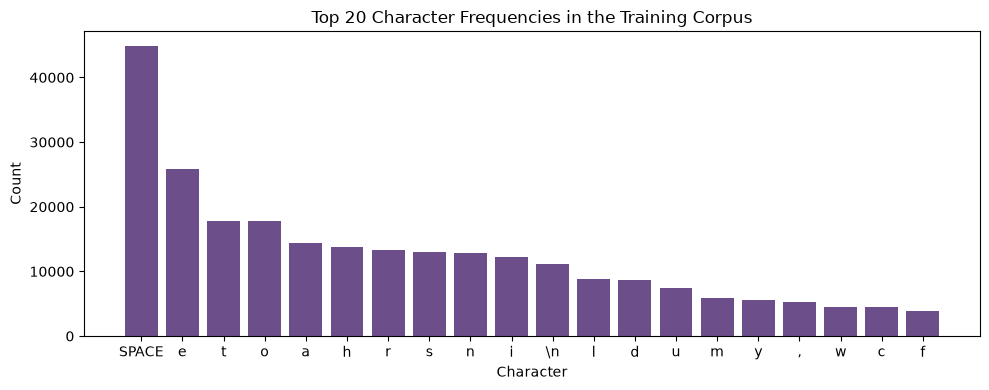

In [5]:
freqs = Counter(text)
most_common = freqs.most_common(20)
labels, counts = zip(*most_common)
labels = ['SPACE' if l == ' ' else ('\\n' if l == '\n' else l) for l in labels]

plt.figure(figsize=(10, 4))
plt.bar(labels, counts, color="#6c4f8a")
plt.title("Top 20 Character Frequencies in the Training Corpus")
plt.xlabel("Character")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4 Train / Validation Split & Batching

In [6]:
data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print(f"Train: {len(train_data):,} tokens | Val: {len(val_data):,} tokens")

def get_batch(split):
    source = train_data if split == 'train' else val_data
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i + block_size] for i in ix])
    y = torch.stack([source[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

Train: 270,000 tokens | Val: 30,000 tokens


## 5 Build the Model — GPT-style Decoder

A multi-head causal self-attention Transformer (fused-QKV projection, pre-LayerNorm blocks, GELU feed-forward, weight tying between the embedding and output layers, GPT-2 style residual initialization).

In [7]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention with fused QKV projection"""

    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.dropout_p = dropout

        self.c_attn = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.c_proj = nn.Linear(n_embd, n_embd, bias=False)
        self.dropout = nn.Dropout(dropout)

        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size))
                              .view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.shape

        qkv = self.c_attn(x)
        q, k, v = qkv.split(C, dim=2)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        out = F.scaled_dot_product_attention(
            q, k, v, is_causal=True,
            dropout_p=self.dropout_p if self.training else 0.0,
        )

        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.c_proj(out)
        out = self.dropout(out)
        return out


class FeedForward(nn.Module):
    """FFN with GELU activation"""

    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Transformer block with Pre-LayerNorm"""

    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffwd = FeedForward(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

        # Weight tying
        self.token_embedding_table.weight = self.lm_head.weight

        self.apply(self._init_weights)
        for name, p in self.named_parameters():
            if name.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, index, targets=None):
        B, T = index.shape
        tok_emb = self.token_embedding_table(index)
        pos_emb = self.position_embedding_table(torch.arange(T, device=index.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    @torch.no_grad()
    def generate(self, index, max_new_tokens, temperature=0.8, top_k=40, repetition_penalty=1.0):
        """Generation with temperature, top-k sampling, and a repetition penalty
        (a small problem-solving addition: without it, small char-models love to
        get stuck in loops like 'the the the the...')."""
        for _ in range(max_new_tokens):
            index_cond = index[:, -self.block_size:]
            logits, _ = self.forward(index_cond)
            logits = logits[:, -1, :] / temperature

            if repetition_penalty != 1.0:
                for token_id in set(index[0].tolist()):
                    logits[0, token_id] /= repetition_penalty

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            index_next = torch.multinomial(probs, num_samples=1)
            index = torch.cat((index, index_next), dim=1)
        return index


model = GPTLanguageModel(vocab_size, n_embd, n_head, n_layer, block_size, dropout)
m = model.to(device)
print(f"Model parameters: {sum(p.numel() for p in m.parameters()):,}")

Model parameters: 1,813,248


## 6 Evaluation Helper (with loss history for plotting)

In [8]:
train_losses, val_losses, steps_list, perplexities = [], [], [], []

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## 7 Optimizer + Cosine LR Schedule with Warmup

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1)

def get_lr(it):
    min_lr = learning_rate / 10
    if it < warmup_iters:
        return learning_rate * (it + 1) / warmup_iters
    decay_ratio = (it - warmup_iters) / max(1, (max_iters - warmup_iters))
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)

## 8 Train Tom / Load a Checkpoint

If `LOAD_CHECKPOINT = True` and `tom_shakespeare.pt` exists, training is skipped entirely — handy once you've already trained Tom once.

In [10]:
if LOAD_CHECKPOINT and os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    print(f"Loaded checkpoint from '{checkpoint_path}'. Skipping training.")
else:
    for it in range(max_iters):
        lr = get_lr(it)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        if it % eval_interval == 0 or it == max_iters - 1:
            losses = estimate_loss()
            train_losses.append(losses['train'].item())
            val_losses.append(losses['val'].item())
            perplexities.append(math.exp(losses['val'].item()))
            steps_list.append(it)
            print(f"step {it:5d} | lr {lr:.2e} | train {losses['train']:.4f} | val {losses['val']:.4f} | val perplexity {perplexities[-1]:.2f}")

        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

    print(f"\nTraining complete. Final train loss: {loss.item():.4f}")

step     0 | lr 2.00e-06 | train 4.1358 | val 4.1333 | val perplexity 62.38
step   200 | lr 3.00e-04 | train 2.4002 | val 2.4776 | val perplexity 11.91
step   400 | lr 2.88e-04 | train 2.1972 | val 2.2442 | val perplexity 9.43
step   600 | lr 2.62e-04 | train 2.0053 | val 2.0356 | val perplexity 7.66
step   800 | lr 2.26e-04 | train 1.8642 | val 1.8961 | val perplexity 6.66
step  1000 | lr 1.82e-04 | train 1.7591 | val 1.7916 | val perplexity 6.00
step  1200 | lr 1.37e-04 | train 1.6778 | val 1.7267 | val perplexity 5.62
step  1400 | lr 9.42e-05 | train 1.6210 | val 1.6712 | val perplexity 5.32
step  1600 | lr 6.00e-05 | train 1.5824 | val 1.6409 | val perplexity 5.16
step  1800 | lr 3.77e-05 | train 1.5546 | val 1.6184 | val perplexity 5.04
step  1999 | lr 3.00e-05 | train 1.5425 | val 1.6141 | val perplexity 5.02

Training complete. Final train loss: 1.6491


## 9 Visualize Training

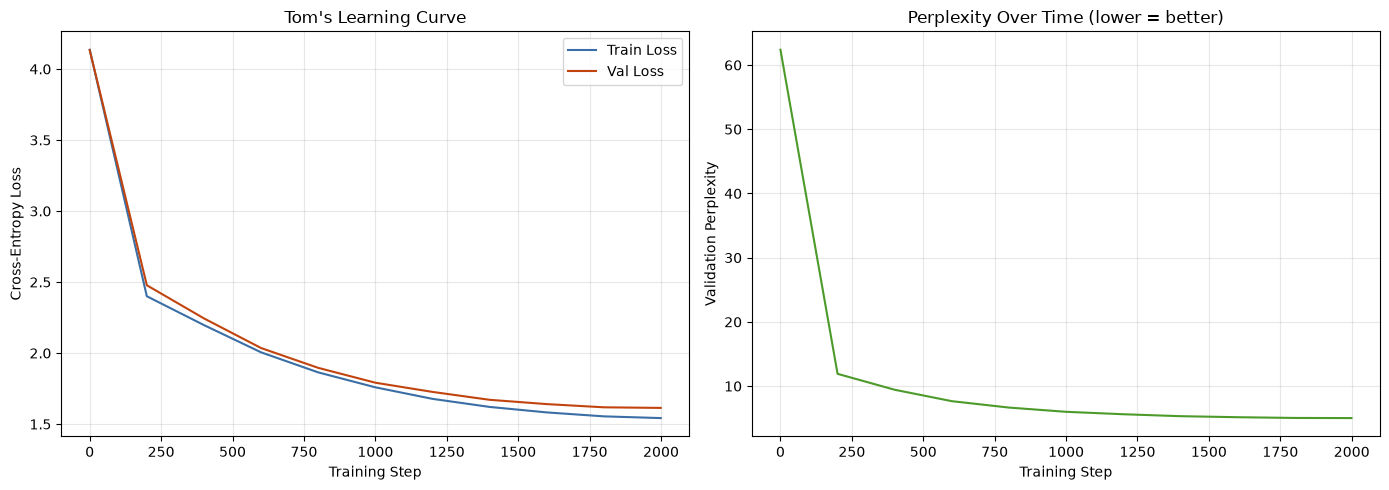

In [11]:
if steps_list:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(steps_list, train_losses, label="Train Loss", color="#3a6ea5")
    axes[0].plot(steps_list, val_losses, label="Val Loss", color="#c1440e")
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].set_title("Tom's Learning Curve")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(steps_list, perplexities, color="#4c9a2a")
    axes[1].set_xlabel("Training Step")
    axes[1].set_ylabel("Validation Perplexity")
    axes[1].set_title("Perplexity Over Time (lower = better)")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No training history to plot (a checkpoint was loaded instead).")

## 10 Save Checkpoint

In [12]:
torch.save({
    "model_state_dict": model.state_dict(),
    "vocab": chars,
    "vocab_size": vocab_size,
    "config": dict(n_embd=n_embd, n_head=n_head, n_layer=n_layer,
                    block_size=block_size, dropout=dropout),
}, checkpoint_path)
print(f"Model checkpoint saved to '{checkpoint_path}'")

Model checkpoint saved to 'tom_shakespeare.pt'


## 11 The Shakespearean Style Layer

A char-GPT this small, trained for a couple thousand steps, will pick up Shakespearean *rhythm*
and *spelling* but won't reliably nail Elizabethan *grammar*. So we add a lightweight, rule-based
"Bard filter" on top of the model's raw output (and even on the user's own input, if needed).
This is what actually guarantees Tom answers in Shakespearean style regardless of how well-trained
the underlying model is, and regardless of whether *you* type modern or old English.

In [13]:
SHAKESPEAREAN_MAP = {
    "you": "thou", "you're": "thou art", "your": "thy", "yours": "thine",
    "you'll": "thou shalt", "you've": "thou hast", "are": "art",
    "will": "shall", "don't": "dost not", "doesn't": "doth not",
    "cannot": "cannot", "can't": "canst not", "my": "mine",
    "yes": "aye", "no": "nay", "hello": "well met", "hi": "well met",
    "friend": "good friend", "very": "most", "before": "ere",
    "children": "younglings", "stop": "cease", "quickly": "posthaste",
    "always": "evermore", "never": "ne'er", "over": "o'er",
    "sad": "forlorn", "happy": "merry", "beautiful": "fair",
    "ugly": "foul", "girl": "maiden", "boy": "lad", "old": "aged",
    "listen": "hark", "look": "behold", "why": "wherefore",
    "here": "hither", "there": "thither", "man": "sir", "sir": "sir",
}

EXCLAMATIONS = ["Verily!", "Hark!", "Prithee!", "Forsooth!", "Marry!", "Zounds!"]

def shakespearify(sentence: str) -> str:
    """Nudge any English sentence toward Shakespearean flavor via word substitution."""
    words = sentence.split()
    new_words = []
    for w in words:
        stripped = w.strip(".,!?;:")
        suffix = w[len(stripped):]
        replacement = SHAKESPEAREAN_MAP.get(stripped.lower())
        if replacement:
            if stripped[:1].isupper():
                replacement = replacement.capitalize()
            new_words.append(replacement + suffix)
        else:
            new_words.append(w)
    result = ' '.join(new_words)
    if result and random.random() < 0.25:
        result = f"{random.choice(EXCLAMATIONS)} {result}"
    return result

## 12 Fine-Tune an English-Speaking Tom (Transfer Learning)

Tom's Transformer above only ever saw Shakespeare's plays, so left to itself it can only ever
sound like Shakespeare -- the "English" mode in the chat below isn't a different personality of
the *same* model, it's a **second model**.

Rather than training that second model from scratch, we initialize it from Tom's already-trained
Shakespeare weights -- transfer learning: reuse the character embeddings, attention patterns, and
general sentence structure the model already learned -- and continue training ("fine-tune") it for
a modest number of extra steps on a modern English dialogue corpus. The result is saved to its own
checkpoint (`tom_english.pt`), so the original `tom_shakespeare.pt` weights are never touched --
both "personalities" of Tom stay available side by side.

In [14]:
# --- English fine-tuning configuration ---
ENGLISH_DATA_URL  = "https://raw.githubusercontent.com/Phylliida/Dialogue-Datasets/master/MovieCorpus.txt"
ENGLISH_DATA_FILE = "english_dialogue.txt"
ENGLISH_MAX_CHARS = 600_000

ft_max_iters     = 1500
ft_eval_interval = 150
ft_eval_iters    = 50
ft_learning_rate = 2.5e-4  

ft_warmup_iters  = 100
ft_grad_clip     = 1.0

checkpoint_path_english = "tom_english.pt"
LOAD_ENGLISH_CHECKPOINT = False   # flip to True after you've fine-tuned once, to skip re-training

In [15]:
def download_english_corpus():
    if os.path.exists(ENGLISH_DATA_FILE):
        print(f"Found existing '{ENGLISH_DATA_FILE}', skipping download.")
        return
    try:
        print("Downloading modern English dialogue corpus...")
        urllib.request.urlretrieve(ENGLISH_DATA_URL, ENGLISH_DATA_FILE)
        print("Download complete.")
    except Exception as e:
        print(f"Download failed ({e}). English fine-tuning will be skipped; chat will fall back to Shakespearean tongue.")

download_english_corpus()

english_text = ""
if os.path.exists(ENGLISH_DATA_FILE):
    with open(ENGLISH_DATA_FILE, 'r', encoding='utf-8', errors='ignore') as f:
        english_text = f.read()

    if ENGLISH_MAX_CHARS:
        english_text = english_text[:ENGLISH_MAX_CHARS]

    # Tom's vocabulary is fixed by the Shakespeare corpus (the checkpoint's embedding and
    # output layers are sized to it), so any character this English corpus has that Tom has
    # never seen gets dropped here -- rather than training him on a placeholder character.
    english_text = ''.join(c for c in english_text if c in string_to_int)

print(f"English corpus length (after filtering to Tom's vocabulary): {len(english_text):,} characters")

Found existing 'english_dialogue.txt', skipping download.
English corpus length (after filtering to Tom's vocabulary): 596,736 characters


In [16]:
english_train_data, english_val_data = None, None

if english_text:
    english_data = torch.tensor(encode(english_text), dtype=torch.long)
    n_eng = int(0.9 * len(english_data))
    english_train_data = english_data[:n_eng]
    english_val_data = english_data[n_eng:]
    print(f"English train: {len(english_train_data):,} tokens | val: {len(english_val_data):,} tokens")

def get_batch_english(split):
    source = english_train_data if split == 'train' else english_val_data
    ix = torch.randint(len(source) - block_size, (batch_size,))
    x = torch.stack([source[i:i + block_size] for i in ix])
    y = torch.stack([source[i + 1:i + 1 + block_size] for i in ix])
    return x.to(device), y.to(device)

English train: 537,062 tokens | val: 59,674 tokens


In [17]:
model_english = None

if english_train_data is not None and len(english_train_data) > block_size:
    model_english = GPTLanguageModel(vocab_size, n_embd, n_head, n_layer, block_size, dropout).to(device)

    if LOAD_ENGLISH_CHECKPOINT and os.path.exists(checkpoint_path_english):
        ckpt = torch.load(checkpoint_path_english, map_location=device)
        model_english.load_state_dict(ckpt["model_state_dict"])
        print(f"Loaded checkpoint from '{checkpoint_path_english}'. Skipping fine-tuning.")
    else:
        # Transfer learning: start from Tom's trained Shakespeare weights instead of a
        # random initialization, then fine-tune on the English corpus.
        model_english.load_state_dict(model.state_dict())

        ft_optimizer = torch.optim.AdamW(model_english.parameters(), lr=ft_learning_rate,
                                          betas=(0.9, 0.95), weight_decay=0.1)

        def get_ft_lr(it):
            min_lr = ft_learning_rate / 10
            if it < ft_warmup_iters:
                return ft_learning_rate * (it + 1) / ft_warmup_iters
            decay_ratio = min((it - ft_warmup_iters) / max(1, (ft_max_iters - ft_warmup_iters)), 1.0)
            coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
            return min_lr + coeff * (ft_learning_rate - min_lr)

        @torch.no_grad()
        def estimate_english_loss():
            out = {}
            model_english.eval()
            for split in ['train', 'val']:
                losses = torch.zeros(ft_eval_iters)
                for k in range(ft_eval_iters):
                    X, Y = get_batch_english(split)
                    _, loss = model_english(X, Y)
                    losses[k] = loss.item()
                out[split] = losses.mean().item()
            model_english.train()
            return out

        ft_train_losses, ft_val_losses, ft_steps = [], [], []

        model_english.train()
        for it in range(ft_max_iters):
            lr = get_ft_lr(it)
            for pg in ft_optimizer.param_groups:
                pg['lr'] = lr

            X, Y = get_batch_english('train')
            _, loss = model_english(X, Y)
            ft_optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_english.parameters(), ft_grad_clip)
            ft_optimizer.step()

            if it % ft_eval_interval == 0 or it == ft_max_iters - 1:
                losses = estimate_english_loss()
                ft_train_losses.append(losses['train'])
                ft_val_losses.append(losses['val'])
                ft_steps.append(it)
                print(f"step {it:4d} | English train loss {losses['train']:.4f} | val loss {losses['val']:.4f}")

        torch.save({
            "model_state_dict": model_english.state_dict(),
            "vocab": chars,
            "vocab_size": vocab_size,
            "config": dict(n_embd=n_embd, n_head=n_head, n_layer=n_layer,
                            block_size=block_size, dropout=dropout),
        }, checkpoint_path_english)
        print(f"English model checkpoint saved to '{checkpoint_path_english}'")
else:
    print("English corpus unavailable -- 'English' chat mode will fall back to Shakespearean mode.")

step    0 | English train loss 2.3635 | val loss 2.4142
step  150 | English train loss 1.7809 | val loss 1.7765
step  300 | English train loss 1.7027 | val loss 1.7141
step  450 | English train loss 1.6484 | val loss 1.6808
step  600 | English train loss 1.6047 | val loss 1.6477
step  750 | English train loss 1.5694 | val loss 1.6069
step  900 | English train loss 1.5437 | val loss 1.5958
step 1050 | English train loss 1.5227 | val loss 1.5758
step 1200 | English train loss 1.5068 | val loss 1.5684
step 1350 | English train loss 1.4987 | val loss 1.5589
step 1499 | English train loss 1.4870 | val loss 1.5542
English model checkpoint saved to 'tom_english.pt'


### Fine-tuning loss (English)

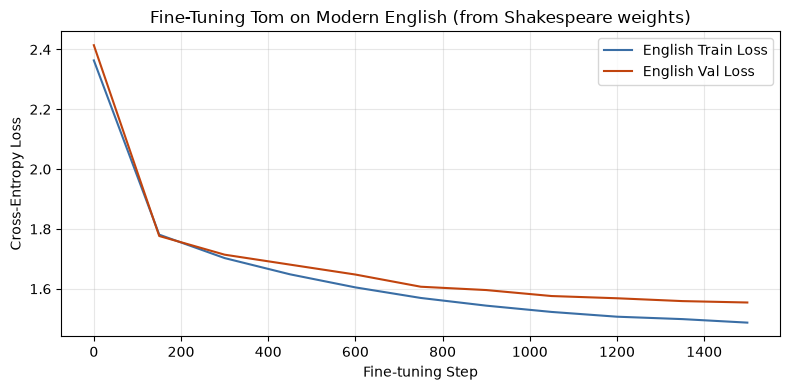

In [18]:
if english_train_data is not None and 'ft_steps' in dir() and ft_steps:
    plt.figure(figsize=(8, 4))
    plt.plot(ft_steps, ft_train_losses, label="English Train Loss", color="#3a6ea5")
    plt.plot(ft_steps, ft_val_losses, label="English Val Loss", color="#c1440e")
    plt.xlabel("Fine-tuning Step")
    plt.ylabel("Cross-Entropy Loss")
    plt.title("Fine-Tuning Tom on Modern English (from Shakespeare weights)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No fine-tuning run to plot (English model was loaded from checkpoint or unavailable).")

## 13 Generation Helpers with perplexity tool

In [19]:
def clean_input(user_text: str) -> str:
    """Keep only characters Tom's vocabulary knows, so he never crashes on
    emoji or unseen symbols the model has never seen."""
    cleaned = ''.join(c for c in user_text if c in string_to_int)
    return cleaned if cleaned.strip() else ' '


def generate_reply(prompt, model_obj=None, max_new_tokens=150, temperature=0.8, top_k=40, repetition_penalty=1.3):
    """model_obj lets the caller pick which Tom answers -- the Shakespeare-trained `m`
    (default) or the fine-tuned `model_english` -- without duplicating this function."""
    model_obj = model_obj if model_obj is not None else m
    context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    out = model_obj.generate(context, max_new_tokens=max_new_tokens, temperature=temperature,
                              top_k=top_k, repetition_penalty=repetition_penalty)
    new_tokens = out[0, context.shape[1]:].tolist()
    return decode(new_tokens)


@torch.no_grad()
def sentence_perplexity(sentence: str, model_obj=None) -> float:
    """Bonus tool: how 'surprised' is Tom by a sentence, according to his
    own learned probabilities? Lower = more familiar to him."""
    model_obj = model_obj if model_obj is not None else model
    ids = encode(sentence)
    if len(ids) < 2:
        return float('nan')
    x = torch.tensor([ids[:-1]], dtype=torch.long, device=device)[:, -block_size:]
    y = torch.tensor([ids[1:]], dtype=torch.long, device=device)[:, -block_size:]
    model_obj.eval()
    _, loss = model_obj(x, y)
    model_obj.train()
    return math.exp(loss.item())


CONVERSATION_LOG_FILE = "tom_conversation_history.json"

# Global transcript store. Two safety nets so Section 15 never loses data:
#  1) Don't wipe an existing in-memory transcript if this cell gets re-run by accident
#     after a chat already happened.
#  2) If no in-memory transcript exists yet, recover the last saved one from disk --
#     covers a kernel restart or a fresh run of just this cell + Section 15.
if 'conversation_history' not in globals() or not conversation_history:
    if os.path.exists(CONVERSATION_LOG_FILE):
        try:
            with open(CONVERSATION_LOG_FILE, 'r', encoding='utf-8') as f:
                conversation_history = json.load(f)
            print(f"Recovered {len(conversation_history)} saved turn(s) from '{CONVERSATION_LOG_FILE}'.")
        except Exception:
            conversation_history = []
    else:
        conversation_history = []

## 14 Chat With Tom

Run the cell below and start talking. You'll first be asked whether Tom should reply in
**Shakespearean** tongue (his original trained voice, polished with a rule-based style filter)
or plain **English** (a second model, fine-tuned from Tom's Shakespeare weights on a modern
dialogue corpus -- see Section 12). You can type `switch language` at any point during the chat
to flip between the two. Say **`bye tom`** (or `bye` / `exit` / `quit`) whenever you want to end
the conversation.

If you need to stop early (kernel interrupt), whatever was said so far is kept -- Section 15
will still show it instead of reporting "no chat data".

In [22]:
def _ask_style():
    """Ask which tongue Tom should reply in. Loops until a valid choice is given."""
    while True:
        choice = input("Choose Tom's tongue -- [S]hakespearean or [E]nglish: ").strip().lower()
        if choice in ("s", "shake", "shakespeare", "shakespearean"):
            return "shakespearean"
        if choice in ("e", "eng", "english", "modern"):
            return "english"
        print("  Please type 'S' for Shakespearean or 'E' for English.")


def _save_conversation_history():
    """Persist the transcript to disk after every turn, so it survives a kernel
    restart or an accidental re-run of an earlier cell -- Section 15 can recover
    it from here even if the in-memory variable is gone."""
    try:
        with open(CONVERSATION_LOG_FILE, 'w', encoding='utf-8') as f:
            json.dump(conversation_history, f, indent=2)
    except Exception as e:
        print(f"(Warning: could not autosave transcript: {e})")


def chat_with_tom(max_new_tokens=120, temperature=0.8, top_k=40, repetition_penalty=1.3):
    global conversation_history
    conversation_history = []  # fresh transcript each time you start a new chat
    _save_conversation_history()

    print("=" * 64)
    print("  Welcome! Thou standest before TOM, apprentice of the Bard.")
    print("=" * 64)

    style = _ask_style()
    if style == "english" and model_english is None:
        print("\n(No fine-tuned English model is available -- falling back to Shakespearean tongue.)")
        style = "shakespearean"

    print(f"\nTom will now answer in {style.capitalize()} tongue.")
    print("  Type 'switch language' any time to flip tongues,")
    print("  or 'bye tom' (bye/exit/quit) whenever you wish to take your leave.")
    print("=" * 64)

    try:
        while True:
            user_input = input("\nYou: ").strip()
            if not user_input:
                continue

            if user_input.lower() in ("bye tom", "bye", "exit", "quit", "farewell"):
                farewell = ("Fare thee well, gentle friend! Until we meet again."
                            if style == "shakespearean"
                            else "Goodbye! Talk again soon.")
                print(f"\nTom: {farewell}")
                break

            if user_input.lower() in ("switch language", "switch tongue", "change language", "change tongue"):
                new_style = "english" if style == "shakespearean" else "shakespearean"
                if new_style == "english" and model_english is None:
                    print("\n(No fine-tuned English model is available -- staying in Shakespearean tongue.)")
                else:
                    style = new_style
                    print(f"\n(Tom now speaks in {style.capitalize()} tongue.)")
                continue

            cleaned = clean_input(user_input)
            model_obj = model_english if (style == "english" and model_english is not None) else m

            raw_reply = generate_reply(cleaned, model_obj=model_obj, max_new_tokens=max_new_tokens,
                                        temperature=temperature, top_k=top_k,
                                        repetition_penalty=repetition_penalty)
            raw_reply = raw_reply.strip()

            if style == "shakespearean":
                styled_reply = shakespearify(raw_reply) or "Hmm, prithee say more."
            else:
                styled_reply = raw_reply or "Hmm, could you say a bit more?"

            perplexity = sentence_perplexity(cleaned, model_obj=model_obj)

            print(f"Tom: {styled_reply}")
            print(f"     (Tom's surprise at thy words -- perplexity: {perplexity:.1f})")

            # Appended immediately and autosaved to disk -- so an interrupted cell, a
            # kernel restart, or an accidental re-run of an earlier cell can never wipe
            # out a conversation that already happened.
            conversation_history.append({
                "user": user_input,
                "tom": styled_reply,
                "style": style,
                "perplexity": perplexity,
            })
            _save_conversation_history()

    except KeyboardInterrupt:
        # Lets you stop the chat cleanly (e.g. via the kernel interrupt button)
        # instead of leaving the cell "busy" and blocking the next cell.
        print("\n\nTom: (chat interrupted) Fare thee well for now!")

    return conversation_history


conversation_history = chat_with_tom()

  Welcome! Thou standest before TOM, apprentice of the Bard.


Choose Tom's tongue -- [S]hakespearean or [E]nglish:  S



Tom will now answer in Shakespearean tongue.
  Type 'switch language' any time to flip tongues,
  or 'bye tom' (bye/exit/quit) whenever you wish to take your leave.



You:  hi


Tom: s tome That Isul, thou when, do arm, but vering them. MENENIUS: As firggnforace.'s I cust Aoms, mo prister, Nay To sout t
     (Tom's surprise at thy words -- perplexity: 5.9)


...

Tom: u art be unvaling, I mine with chldy Riegrser: and thou Dafight long; So, he think than benglem's hop foour Right sonit, W
     (Tom's surprise at thy words -- perplexity: 5.9)



You:  ye


Tom: wark their gravan. Soy: QUEN ELIZABETHAMhy, I, comes? VOMNIRILIA: Whoave thy forminess apitity, nd masts, Yeing such
     (Tom's surprise at thy words -- perplexity: 51.4)



You:  bye



Tom: Fare thee well, gentle friend! Until we meet again.


## 15 Post-Chat Analytics & Transcript Export

You exchanged 5 turn(s) with Tom.
Transcript saved to 'tom_conversation.txt'


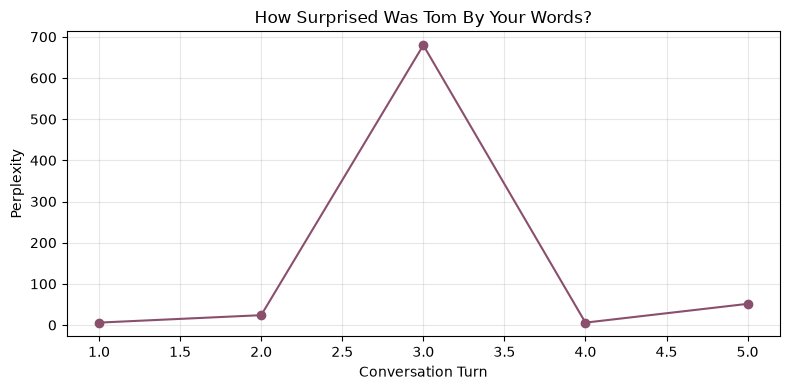

In [23]:
if not conversation_history and os.path.exists(CONVERSATION_LOG_FILE):
    try:
        with open(CONVERSATION_LOG_FILE, 'r', encoding='utf-8') as f:
            conversation_history = json.load(f)
        if conversation_history:
            print(f"(Recovered {len(conversation_history)} turn(s) from '{CONVERSATION_LOG_FILE}'.)")
    except Exception:
        pass

if conversation_history:
    print(f"You exchanged {len(conversation_history)} turn(s) with Tom.")

    with open("tom_conversation.txt", "w", encoding="utf-8") as f:
        for turn in conversation_history:
            style = turn.get("style", "shakespearean")
            f.write(f"You: {turn['user']}\nTom ({style}): {turn['tom']}\n\n")
    print("Transcript saved to 'tom_conversation.txt'")

    perps = [t["perplexity"] for t in conversation_history if not math.isnan(t["perplexity"])]
    if perps:
        plt.figure(figsize=(8, 4))
        plt.plot(range(1, len(perps) + 1), perps, marker='o', color="#8a4f6c")
        plt.xlabel("Conversation Turn")
        plt.ylabel("Perplexity")
        plt.title("How Surprised Was Tom By Your Words?")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("No conversation recorded yet -- run the chat cell above first.")

# Key Takeaways

- A GPT-style decoder (multi-head causal self-attention + pre-LayerNorm blocks + weight tying)
  predicts each character from the *whole* preceding context, not just the last character.
- Training on real Shakespearean text is what makes "talking like Shakespeare" possible in the
  first place -- a language model can only imitate the distribution it was shown.
- A small char-level model trained briefly won't master archaic grammar reliably on its own, so a
  **rule-based Shakespearean style layer** is added on top -- a practical pattern: combine a
  learned model with deterministic post-processing where consistent tone matters more than raw
  model capability.
- **Repetition penalty** and **unknown-character filtering** are small engineering touches that
  make the difference between a demo that works once and a chatbot that survives real user input.
- This notebook is a natural next step after the Bigram Language Model notebook -- same
  character-level tokenization and training loop philosophy, now with a full Transformer decoder,
  live loss/perplexity visualization, and an interactive chat interface on top.
- Future improvements: train longer on the full corpus, switch to BPE tokenization instead of
  characters, increase `n_layer`/`n_embd`, and fine-tune on actual question-answer or dialogue
  pairs rather than raw play text.
- **Transfer learning beats training from scratch for a second "voice":** the English-speaking
  Tom is initialized from the trained Shakespeare weights and fine-tuned briefly on modern
  dialogue, rather than trained from a random init or fine-tuned in place -- reusing learned
  representations and keeping the two checkpoints (and personalities) independent.
